## Loan Approval Prediction System Using Machine Learning ##

## Introduction ##

A Loan Approval Prediction System is a predictive analytics tool designed to assist financial institutions in determining whether a loan applicant is likely to be approved based on historical lending data and various applicant characteristics. It uses machine learning algorithms to analyze past loan records along with applicant details such as income, employment status, credit history, and demographics to generate predictions about an applicant's eligiility.

### 1. Importing Libraries

In [263]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy
import warnings
warnings.filterwarnings('ignore')


from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### 2. Load and Explore the Dataset

In [266]:
df = pd.read_csv('LAP_unclean4.csv')

### Get an overview of the data

In [269]:
print(df.head())
print(df.info())
print(df.describe(include='all'))

    Loan_Id Gender Married Dependents     Education Self_Employed  \
0  LP001868   Male     Yes          0  Not Graduate            No   
1  LP002690   Male     Yes         3+  Not Graduate            No   
2  LP002615   Male     Yes          2      Graduate            No   
3  LP002209   Male      No          0      Graduate           NaN   
4  LP001669   Male     Yes          1      Graduate            No   

   Loan_Amount  Applicant_Income  Co_applicant_Income  Loan_amount_Term  \
0         4301            1041.0                100.0             360.0   
1         5677               0.0                187.0             360.0   
2         2491               0.0                100.0             360.0   
3         4865               0.0                160.0             360.0   
4         6216               0.0                112.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0     Semiurban           Y  
1             NaN         Rural           

## Data Exploration

### 3.1 Categorical Variable

#### 3.1.1 Loan ID

In [274]:
df.Loan_Id.value_counts(dropna=False)

Loan_Id
LP002529    71
LP002693    70
LP001616    68
LP002847    68
LP001546    67
            ..
LP001282    32
LP002585    31
LP001955    31
LP001263    31
LP002301    31
Name: count, Length: 614, dtype: int64

### 3.1.2 Gender

In [277]:
df.Gender.value_counts(dropna=False)

Gender
Male      23837
Female     5535
NaN         628
Name: count, dtype: int64

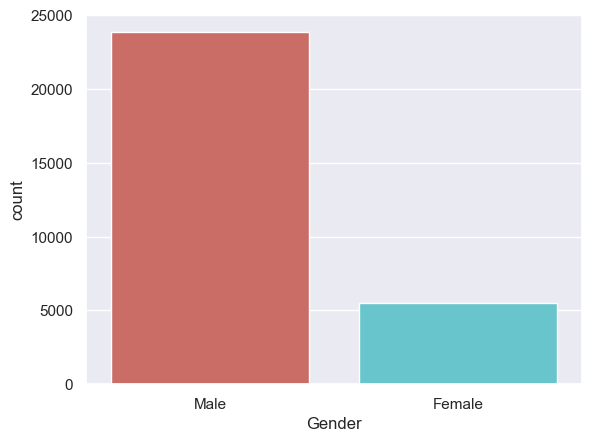

In [279]:
sns.countplot(x="Gender", data=df, palette="hls")
plt.show()

In [280]:
countMale = len(df[df.Gender == 'Male'])
countFemale = len(df[df.Gender == 'Female'])
countNull = len(df[df.Gender.isnull()])

print("Percentage of Male applicant: {:.2f}%".format((countMale / (len(df.Gender))*100)))
print("Percentage of Female applicant: {:.2f}%".format((countFemale / (len(df.Gender))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Gender))*100)))

Percentage of Male applicant: 79.46%
Percentage of Female applicant: 18.45%
Missing values percentage: 2.09%


### 3.1.3 Married

In [284]:
df.Married.value_counts(dropna=False)

Married
Yes    19391
No     10464
NaN      145
Name: count, dtype: int64

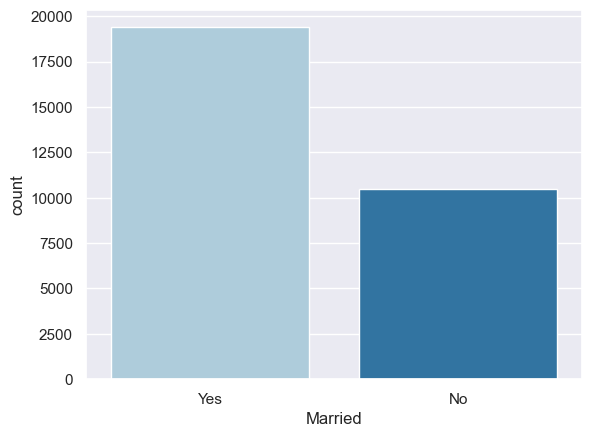

In [286]:
sns.countplot(x="Married", data=df, palette="Paired")
plt.show()

In [287]:
countMarried = len(df[df.Married == 'Yes'])
countNotMarried = len(df[df.Married == 'No'])
countNull = len(df[df.Married.isnull()])

print("Percentage of married: {:.2f}%".format((countMarried / (len(df.Married))*100)))
print("Percentage of Not married applicant: {:.2f}%".format((countNotMarried / (len(df.Married))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Married))*100)))

Percentage of married: 64.64%
Percentage of Not married applicant: 34.88%
Missing values percentage: 0.48%


### 3.1.4 Education

In [291]:
df.Education.value_counts(dropna=False)

Education
Graduate        23505
Not Graduate     6495
Name: count, dtype: int64

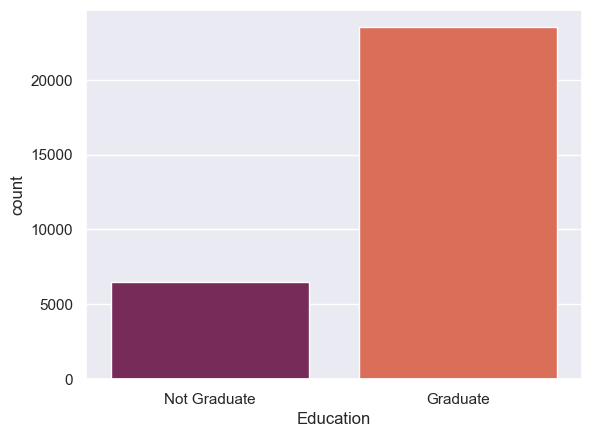

In [293]:
sns.countplot(x="Education", data=df, palette="rocket")
plt.show()

In [295]:
countGraduate = len(df[df.Education == 'Graduate'])
countNotGraduate = len(df[df.Education == 'Not Graduate'])
countNull = len(df[df.Education.isnull()])

print("Percentage of graduate applicant: {:.2f}%".format((countGraduate / (len(df.Education))*100)))
print("Percentage of Not graduate applicant: {:.2f}%".format((countNotGraduate / (len(df.Education))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Education))*100)))

Percentage of graduate applicant: 78.35%
Percentage of Not graduate applicant: 21.65%
Missing values percentage: 0.00%


### 3.1.5 Self Employed

In [298]:
df.Self_Employed.value_counts(dropna=False)

Self_Employed
No     24375
Yes     4074
NaN     1551
Name: count, dtype: int64

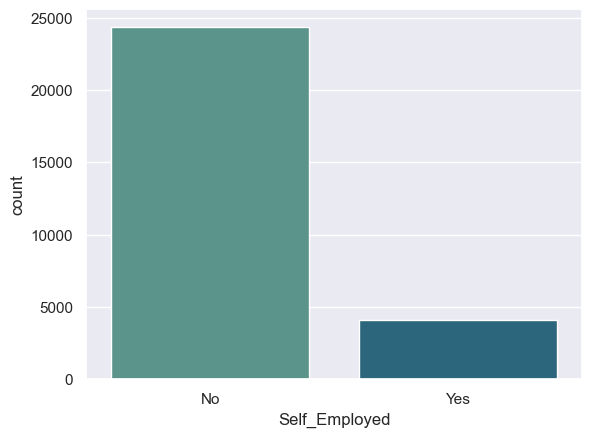

In [300]:
sns.countplot(x="Self_Employed", data=df, palette="crest")
plt.show()

In [301]:
countNo = len(df[df.Self_Employed == 'No'])
countYes = len(df[df.Self_Employed == 'Yes'])
countNull = len(df[df.Self_Employed.isnull()])

print("Percentage of Not self employed: {:.2f}%".format((countNo / (len(df.Self_Employed))*100)))
print("Percentage of self employed: {:.2f}%".format((countYes / (len(df.Self_Employed))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Self_Employed))*100)))

Percentage of Not self employed: 81.25%
Percentage of self employed: 13.58%
Missing values percentage: 5.17%


### 3.1.6 Credit History

In [305]:
df.Credit_History.value_counts(dropna=False)


Credit_History
1.0    23381
0.0     4264
NaN     2355
Name: count, dtype: int64

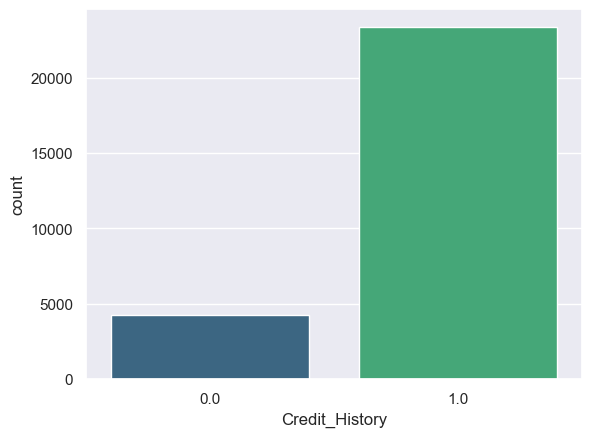

In [307]:
sns.countplot(x="Credit_History", data=df, palette="viridis")
plt.show()

In [308]:
count1 = len(df[df.Credit_History == 1])
count0 = len(df[df.Credit_History == 0])
countNull = len(df[df.Credit_History.isnull()])

print("Percentage of Good credit history: {:.2f}%".format((count1 / (len(df.Credit_History))*100)))
print("Percentage of Bad credit history: {:.2f}%".format((count0 / (len(df.Credit_History))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Credit_History))*100)))

Percentage of Good credit history: 77.94%
Percentage of Bad credit history: 14.21%
Missing values percentage: 7.85%


### 3.1.7 Property Area

In [312]:
df.Property_Area.value_counts(dropna=False)

Property_Area
Semiurban    11379
Urban         9838
Rural         8783
Name: count, dtype: int64

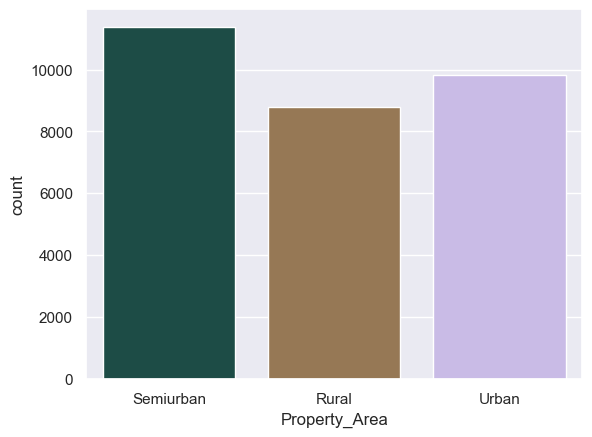

In [314]:
sns.countplot(x="Property_Area", data=df, palette="cubehelix")
plt.show()

In [315]:
countUrban = len(df[df.Property_Area == 'Urban'])
countRural = len(df[df.Property_Area == 'Rural'])
countSemiurban = len(df[df.Property_Area == 'Semiurban'])
countNull = len(df[df.Property_Area.isnull()])

print("Percentage of Urban: {:.2f}%".format((countUrban / (len(df.Property_Area))*100)))
print("Percentage of Rural: {:.2f}%".format((countRural / (len(df.Property_Area))*100)))
print("Percentage of Semiurban: {:.2f}%".format((countSemiurban / (len(df.Property_Area))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Property_Area))*100)))

Percentage of Urban: 32.79%
Percentage of Rural: 29.28%
Percentage of Semiurban: 37.93%
Missing values percentage: 0.00%


### 3.1.8 Loan Status

In [319]:
df.Loan_Status.value_counts(dropna=False)

Loan_Status
Y    20649
N     9351
Name: count, dtype: int64

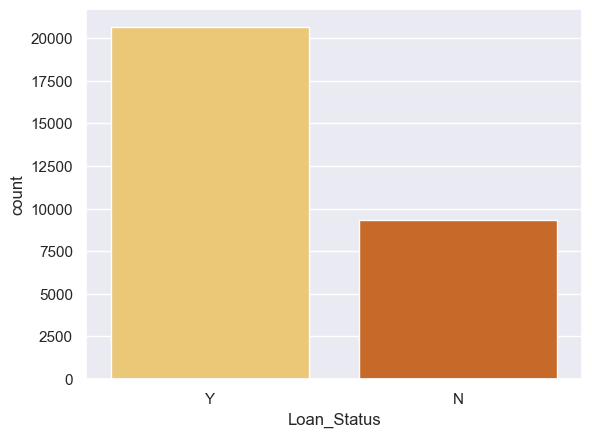

In [321]:
sns.countplot(x="Loan_Status", data=df, palette="YlOrBr")
plt.show()

In [322]:
countY = len(df[df.Loan_Status == 'Y'])
countN = len(df[df.Loan_Status == 'N'])
countNull = len(df[df.Loan_Status.isnull()])

print("Percentage of Approved: {:.2f}%".format((countY / (len(df.Loan_Status))*100)))
print("Percentage of Rejected: {:.2f}%".format((countN / (len(df.Loan_Status))*100)))
print("Missing values percentage: {:.2f}%".format((countNull / (len(df.Loan_Status))*100)))

Percentage of Approved: 68.83%
Percentage of Rejected: 31.17%
Missing values percentage: 0.00%


### 3.1.9 Loan Ammount Term

In [326]:
df.Loan_amount_Term.value_counts(dropna=False)

Loan_amount_Term
360.0    25034
180.0     2156
480.0      700
NaN        680
300.0      637
240.0      202
84.0       196
120.0      141
60.0       107
36.0       103
12.0        44
Name: count, dtype: int64

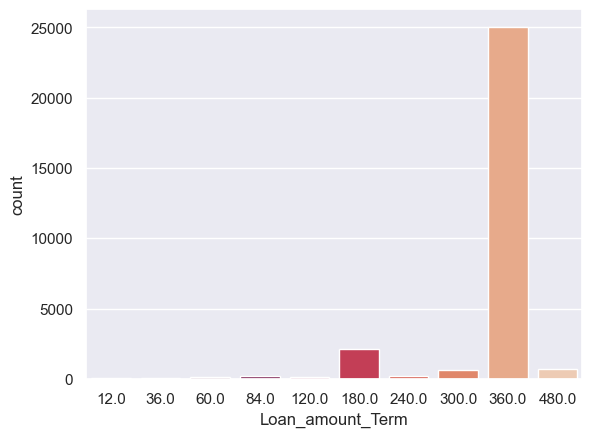

In [327]:
sns.countplot(x="Loan_amount_Term", data=df, palette="rocket")
plt.show()

## 3.2 Numerical variable

### 3.2.1 Discribe numerical variable

In [333]:
df[['Applicant_Income','Co_applicant_Income','Loan_Amount']].describe()

,Applicant_Income,Co_applicant_Income,Loan_Amount
count,30000.000000,28910.000000,30000.000000
mean,1614.479276,146.615047,5455.081433
std,2891.007159,85.268223,6220.108760
min,0.000000,9.000000,150.000000
25%,0.000000,100.000000,2882.000000
50%,1229.000000,128.000000,3816.000000
75%,2302.000000,168.000000,5815.750000
max,41667.000000,700.000000,81000.000000


## 3.2.2 Distribution of numerical variable 

### 3.2.2.1 Histogram Distribution

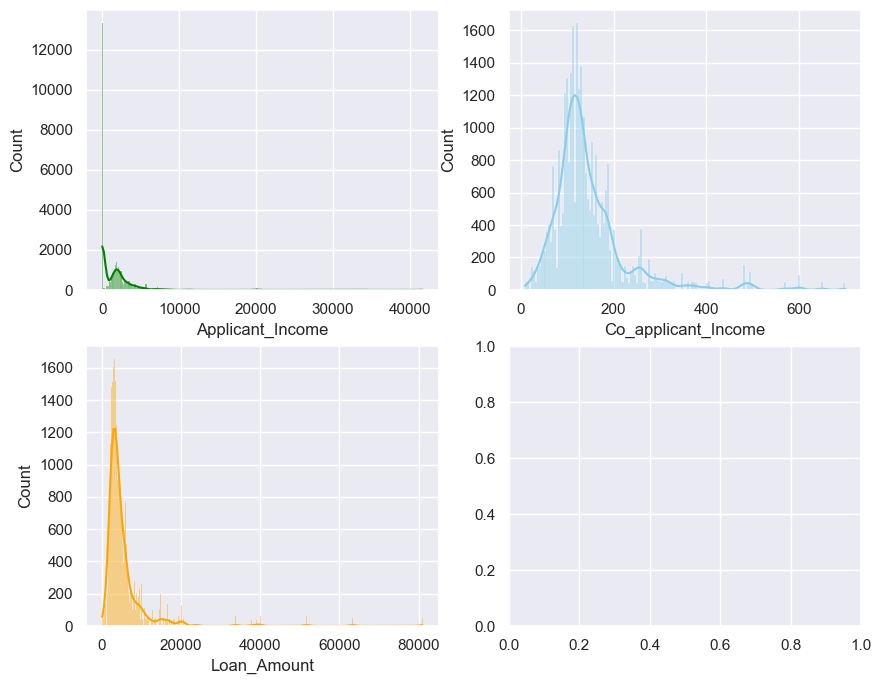

In [337]:
sns.set(style="darkgrid")
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(data=df, x="Applicant_Income", kde=True, ax=axs[0, 0], color='green')
sns.histplot(data=df, x="Co_applicant_Income", kde=True, ax=axs[0, 1], color='skyblue')
sns.histplot(data=df, x="Loan_Amount", kde=True, ax=axs[1, 0], color='orange');

### 3.2.2.2 Heat map

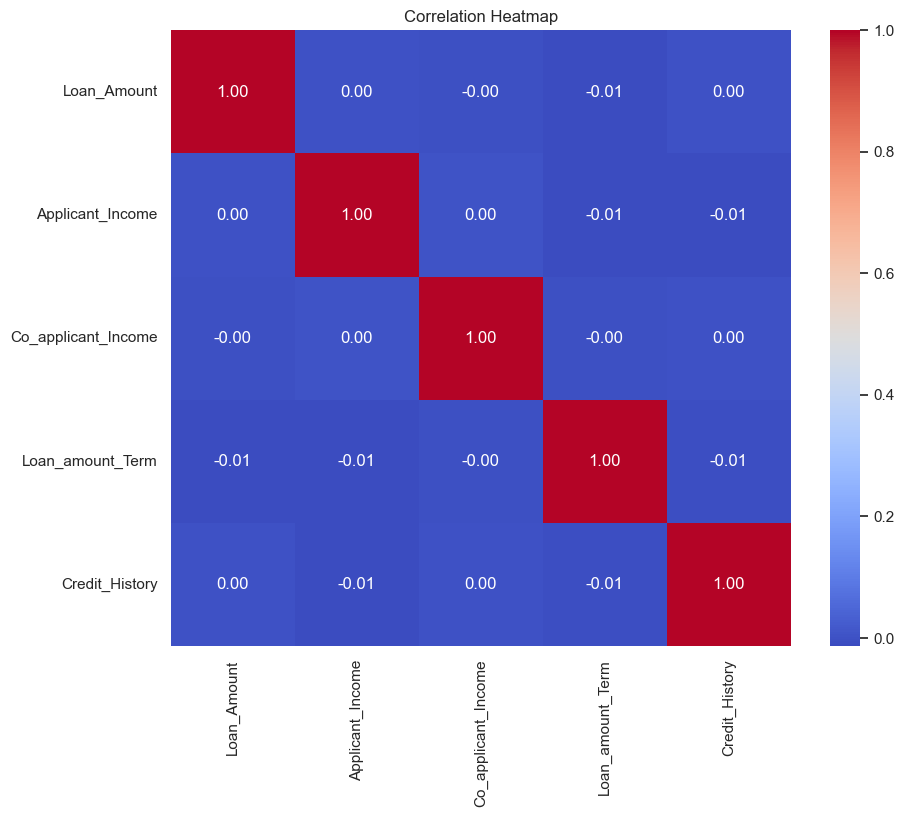

In [339]:
numeric_df = df.select_dtypes(include='number')
# Correlation matrix to find relationships between numerical columns
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## 3.3.1 Comparing Categorical columns

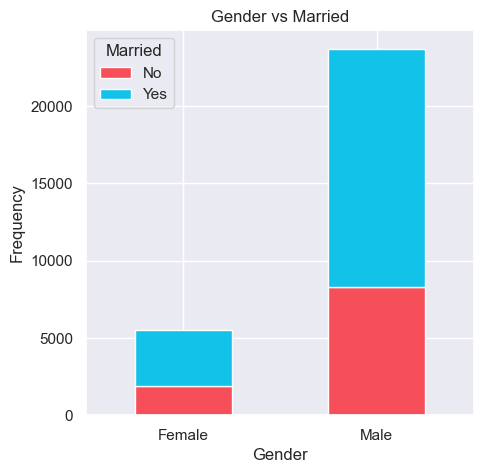

In [341]:
pd.crosstab(df.Gender,df.Married).plot(kind="bar", stacked=True, figsize=(5,5), color=['#f64f59','#12c2e9'])
plt.title('Gender vs Married')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

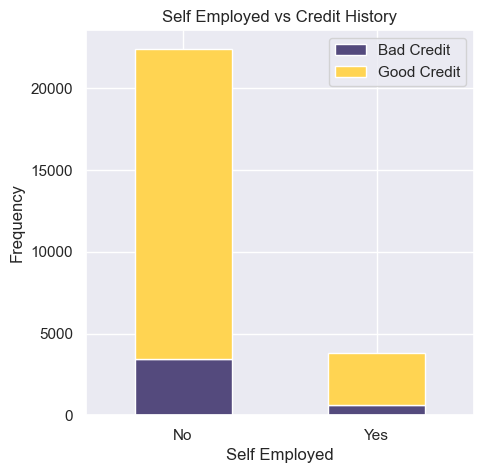

In [342]:
pd.crosstab(df.Self_Employed,df.Credit_History).plot(kind="bar", stacked=True, figsize=(5,5), color=['#544a7d','#ffd452'])
plt.title('Self Employed vs Credit History')
plt.xlabel('Self Employed')
plt.ylabel('Frequency')
plt.legend(["Bad Credit", "Good Credit"])
plt.xticks(rotation=0)
plt.show()

## Data Preprocessing 

### 4.1 Drop Unecessary Variables 

In [345]:
df = df.drop(['Loan_Id'], axis = 1)
df = df.drop(['Property_Area'], axis = 1)

### 4.2 Data Imputation

In [347]:
print(df.isnull().sum())

Gender                  628
Married                 145
Dependents              724
Education                 0
Self_Employed          1551
Loan_Amount               0
Applicant_Income          0
Co_applicant_Income    1090
Loan_amount_Term        680
Credit_History         2355
Loan_Status               0
dtype: int64


### 5.2.1 Categorical Variables

In [349]:
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
df['Married'].fillna(df['Married'].mode()[0],inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0],inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0],inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0],inplace=True)
df['Education'].fillna(df['Education'].mode()[0],inplace=True)


In [357]:
print(df.isnull().sum())

Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
Loan_Amount               0
Applicant_Income          0
Co_applicant_Income    1090
Loan_amount_Term        680
Credit_History            0
Loan_Status               0
dtype: int64


### 4.2.2 Numerical Variables

In [360]:
df['Loan_Amount'].fillna(df['Loan_Amount'].mean(),inplace=True)
df['Co_applicant_Income'].fillna(df['Co_applicant_Income'].mean(),inplace=True)
df['Applicant_Income'].fillna(df['Applicant_Income'].mean(),inplace=True)
df['Loan_amount_Term'].fillna(df['Loan_amount_Term'].mean(),inplace=True)

In [362]:
print(df.isnull().sum())

Gender                 0
Married                0
Dependents             0
Education              0
Self_Employed          0
Loan_Amount            0
Applicant_Income       0
Co_applicant_Income    0
Loan_amount_Term       0
Credit_History         0
Loan_Status            0
dtype: int64


## 4.3 One-hot Encoding

In [365]:
df = pd.get_dummies(df)

# Drop columns
df = df.drop(['Gender_Female', 'Married_No', 'Education_Not Graduate', 
              'Self_Employed_No', 'Loan_Status_N'], axis = 1)

# Rename columns name
new = {'Gender_Male': 'Gender', 'Married_Yes': 'Married', 
       'Education_Graduate': 'Education', 'Self_Employed_Yes': 'Self_Employed',
       'Loan_Status_Y': 'Loan_Status'}
       
df.rename(columns=new, inplace=True)

In [367]:
print(df.head())

   Loan_Amount  Applicant_Income  Co_applicant_Income  Loan_amount_Term  \
0         4301            1041.0                100.0             360.0   
1         5677               0.0                187.0             360.0   
2         2491               0.0                100.0             360.0   
3         4865               0.0                160.0             360.0   
4         6216               0.0                112.0             360.0   

   Credit_History  Gender  Married  Dependents_0  Dependents_1  Dependents_2  \
0             1.0    True     True          True         False         False   
1             1.0    True     True         False         False         False   
2             0.0    True     True         False         False          True   
3             1.0    True    False          True         False         False   
4             1.0    True     True         False          True         False   

   Dependents_3+  Education  Self_Employed  Loan_Status  
0         

## 4.5 Features Separating

Dependent features (Loan_Status) will be seperated from independent features

In [371]:
df= df.dropna(subset=['Loan_Status'])

In [373]:
X = df.drop(["Loan_Status"], axis=1)
y = df["Loan_Status"]

In [375]:
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

## 4.6 SMOTE Technique

In previous exploration, it can be seen that the number between approved and rejected loan is imbalanced. In this section, oversampling technique will be used to avoid overfitting,

In [379]:
X, y = SMOTE().fit_resample(X, y)

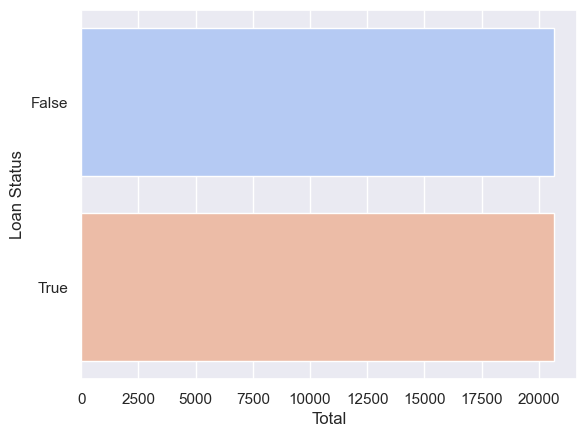

In [380]:
sns.set_theme(style="darkgrid")
sns.countplot(y=y, data=df, palette="coolwarm")
plt.ylabel('Loan Status')
plt.xlabel('Total')
plt.show()

## 4.7 Data Normalization

In this section, data normalization will be performed to normalize the range of independent variables or features of data.

In [385]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


## 4.8 Splitting Data Set

he data set will be split into 80% train and 20% test

In [389]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## 4.9 Save the entire dataset


In [393]:
df.to_csv("dataset_before_model_building_updated3.csv", index=False)
print("✅ Dataset saved successfully as 'dataset_before_model_building.csv'")

✅ Dataset saved successfully as 'dataset_before_model_building.csv'


In [394]:
print(df.head())

   Loan_Amount  Applicant_Income  Co_applicant_Income  Loan_amount_Term  \
0         4301            1041.0                100.0             360.0   
1         5677               0.0                187.0             360.0   
2         2491               0.0                100.0             360.0   
3         4865               0.0                160.0             360.0   
4         6216               0.0                112.0             360.0   

   Credit_History  Gender  Married  Dependents_0  Dependents_1  Dependents_2  \
0             1.0    True     True          True         False         False   
1             1.0    True     True         False         False         False   
2             0.0    True     True         False         False          True   
3             1.0    True    False          True         False         False   
4             1.0    True     True         False          True         False   

   Dependents_3+  Education  Self_Employed  Loan_Status  
0         

In [397]:
print(y.isnull().sum())

0


# 5 Models 

## 6.1 Random Forest

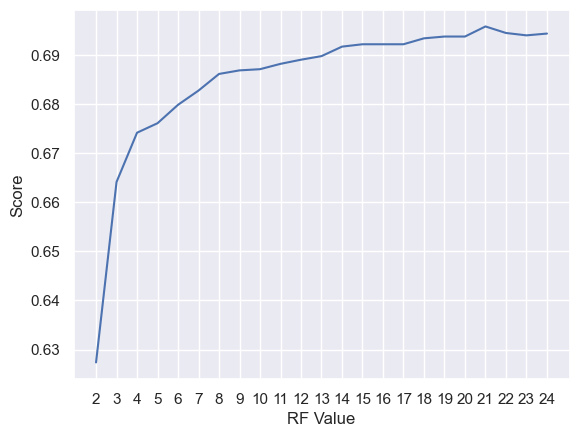

Random Forest Accuracy:  69.59%


In [139]:
scoreListRF = []
for i in range(2,25):
    RFclassifier = RandomForestClassifier(n_estimators = 1000, random_state = 1, max_leaf_nodes=i)
    RFclassifier.fit(X_train, y_train)
    scoreListRF.append(RFclassifier.score(X_test, y_test))
    
plt.plot(range(2,25), scoreListRF)
plt.xticks(np.arange(2,25,1))
plt.xlabel("RF Value")
plt.ylabel("Score")
plt.show()
RFAcc = max(scoreListRF)
print("Random Forest Accuracy:  {:.2f}%".format(RFAcc*100))

## 6.2 LightGBM

In [142]:
!pip install lightgbm


In [238]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
LGBclassifier = LGBMClassifier(subsample=0.5, n_estimators=400, max_depth=4, num_leaves=10)
LGBclassifier.fit(X_train, y_train)
model = LogisticRegression()
model.fit(X, y)

y_pred = LGBclassifier.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

LGBAcc = accuracy_score(y_pred, y_test)
print('LightGBM accuracy: {:.2f}%'.format(LGBAcc * 100))

[LightGBM] [Info] Number of positive: 16511, number of negative: 16527
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003522 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1282
[LightGBM] [Info] Number of data points in the train set: 33038, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499758 -> initscore=-0.000969
[LightGBM] [Info] Start training from score -0.000969
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

## Export Model

In [240]:
import joblib

In [242]:
joblib.dump(model, 'model3.pkl')

['model3.pkl']

## 6.3 XGBoost

In [177]:
 !pip install xgboost

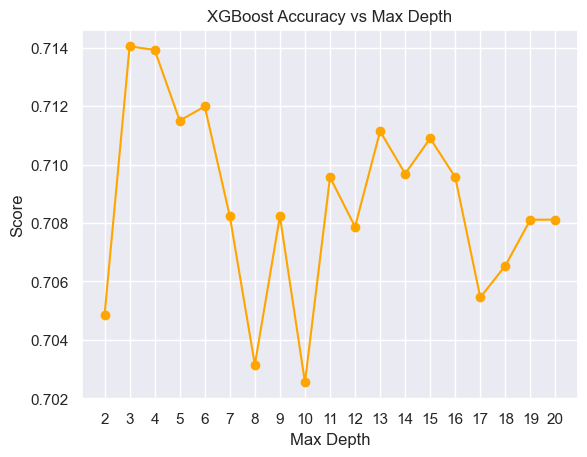

XGBoost Accuracy: 71.40%


In [222]:
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

scoreListXGB = []

# Tune max_depth from 2 to 20
for depth in range(2, 21):
    XGBclassifier = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', max_depth=depth)
    XGBclassifier.fit(X_train, y_train)
    scoreListXGB.append(XGBclassifier.score(X_test, y_test))

# Plot results
plt.plot(range(2, 21), scoreListXGB, marker='o', color='orange')
plt.xticks(np.arange(2, 21, 1))
plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.title("XGBoost Accuracy vs Max Depth")
plt.grid(True)
plt.show()

# Best accuracy
XGBAcc = max(scoreListXGB)
print("XGBoost Accuracy: {:.2f}%".format(XGBAcc * 100))


## 6.5 Decision Tree

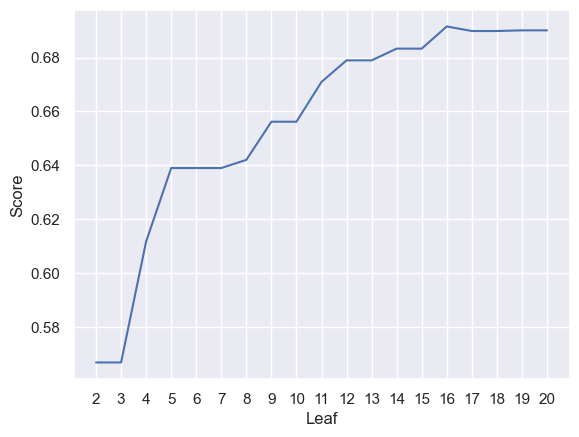

Decision Tree Accuracy: 69.15%


In [217]:
scoreListDT = []
for i in range(2,21):
    DTclassifier = DecisionTreeClassifier(max_leaf_nodes=i)
    DTclassifier.fit(X_train, y_train)
    scoreListDT.append(DTclassifier.score(X_test, y_test))
    
plt.plot(range(2,21), scoreListDT)
plt.xticks(np.arange(2,21,1))
plt.xlabel("Leaf")
plt.ylabel("Score")
plt.show()
DTAcc = max(scoreListDT)
print("Decision Tree Accuracy: {:.2f}%".format(DTAcc*100))

### 6.4 Gradient Boosting

In [216]:
GBclassifier = GradientBoostingClassifier(subsample=0.5, n_estimators=400, max_depth=4, max_leaf_nodes=10)
GBclassifier.fit(X_train, y_train)

y_pred = GBclassifier.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import accuracy_score
GBAcc = accuracy_score(y_pred,y_test)
print('Gradient Boosting accuracy: {:.2f}%'.format(GBAcc*100))

              precision    recall  f1-score   support

       False       0.86      0.54      0.66      4122
        True       0.66      0.92      0.77      4138

    accuracy                           0.73      8260
   macro avg       0.76      0.73      0.72      8260
weighted avg       0.76      0.73      0.72      8260

[[2206 1916]
 [ 347 3791]]
Gradient Boosting accuracy: 72.60%


# 7. Model Comparison

In [399]:
import pandas as pd

# Create the comparison DataFrame
compare = pd.DataFrame({
    'Model': ['LightGBM', 
              'XGBoost', 
              'Decision Tree', 
              'Random Forest', 
              'Gradient Boosting'],
    'Accuracy': [LGBAcc * 100, 
                 XGBAcc * 100, 
                 DTAcc * 100, 
                 RFAcc * 100, 
                 GBAcc * 100]
})

# Sort by Accuracy
compare = compare.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Display
print(compare)


               Model   Accuracy
0           LightGBM  73.050847
1  Gradient Boosting  72.602906
2            XGBoost  71.404358
3      Random Forest  69.588378
4      Decision Tree  69.152542


In [401]:
import pandas as pd
from IPython.display import display, HTML

# Data with emojis
data = {
    'Model': ['LightGBM', 'Gradient Boosting', 'XGBoost', 'Random Forest', 'Decision Tree'],
    'Status': ['✅', '❌', '❌', '❌', '❌'],
    'Accuracy (%)': [73.05, 72.60, 71.40, 69.59, 69.15]
}

df = pd.DataFrame(data)

# Styling: center align text in all cells + center table in notebook
styled_df = df.style.set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]},
     
     {'selector': 'td', 'props': [('text-align', 'center')]}]
).set_properties(**{'text-align': 'center'})

# Display the centered table inside the notebook
display(HTML("<div style='display: flex; justify-content: center'>" + styled_df.to_html() + "</div>"))


,Model,Status,Accuracy (%)
0,LightGBM,✅,73.050000
1,Gradient Boosting,❌,72.600000
2,XGBoost,❌,71.400000
3,Random Forest,❌,69.590000
4,Decision Tree,❌,69.150000
